## ESG Score Predictor for Companies

- Companies are increasingly evaluated on ESG (Environmental, Social, and Governance) performance by investors, regulators, and the public.

- This project uses supervised machine learning (Ridge Regression) to predict the exact ESG Overall Score (0–100) of a company based on its financial performance and sustainability metrics.

- The model replicates the logic used by real-world ESG rating agencies like MSCI and Sustainalytics, and is aligned with UN SDG 8, SDG 13, and SDG 17.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Step 1: Load the Dataset

In [2]:
data = pd.read_csv("company_esg_financial_dataset.csv")

In [3]:
data.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [5]:
data.shape

(11000, 16)

# Step 2: Check for Missing Values

In [6]:
data.isnull().sum()

,0
CompanyID,0
CompanyName,0
Industry,0
Region,0
Year,0
Revenue,0
ProfitMargin,0
MarketCap,0
GrowthRate,1000
ESG_Overall,0


# Step 3: Descriptive Statistics

In [7]:
data.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


# Step 4: Data Preprocessing

In [8]:
# Check all column names
data.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [9]:
# Drop non-predictive columns: CompanyID and CompanyName are identifiers, not features
data = data.drop(columns=["CompanyID", "CompanyName"])

In [10]:
# Fill missing GrowthRate values with the median grouped by Industry
data['GrowthRate'] = data.groupby('Industry')['GrowthRate'].transform(
    lambda x: x.fillna(x.median())
)

print("Missing values after filling:")
print(data.isnull().sum())

Missing values after filling:
Industry             0
Region               0
Year                 0
Revenue              0
ProfitMargin         0
MarketCap            0
GrowthRate           0
ESG_Overall          0
ESG_Environmental    0
ESG_Social           0
ESG_Governance       0
CarbonEmissions      0
WaterUsage           0
EnergyConsumption    0
dtype: int64


In [11]:
# Encode categorical columns: Industry and Region
le_industry = LabelEncoder()
le_region   = LabelEncoder()

data['Industry'] = le_industry.fit_transform(data['Industry'])
data['Region']   = le_region.fit_transform(data['Region'])

print("Industry classes:", list(le_industry.classes_))
print("Region classes  :", list(le_region.classes_))

Industry classes: ['Consumer Goods', 'Energy', 'Finance', 'Healthcare', 'Manufacturing', 'Retail', 'Technology', 'Transportation', 'Utilities']
Region classes  : ['Africa', 'Asia', 'Europe', 'Latin America', 'Middle East', 'North America', 'Oceania']


In [12]:
# Check the cleaned dataset
data.columns

Index(['Industry', 'Region', 'Year', 'Revenue', 'ProfitMargin', 'MarketCap',
       'GrowthRate', 'ESG_Overall', 'ESG_Environmental', 'ESG_Social',
       'ESG_Governance', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [13]:
data.head()

,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,5,3,2015,459.2,6.0,337.5,4.3,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,5,3,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,5,3,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,5,3,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,5,3,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


# Step 5: Exploratory Data Analysis (EDA)

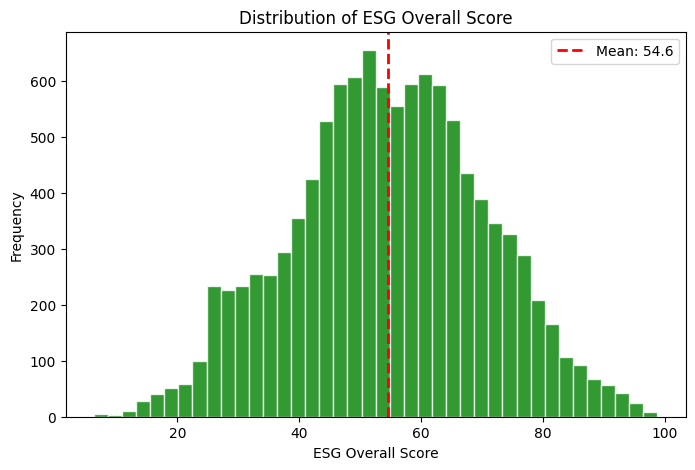

In [14]:
# Univariate Analysis — Distribution of ESG Overall Score (Target Variable)
plt.figure(figsize=(8, 5))
plt.hist(data['ESG_Overall'], bins=40, color='green', edgecolor='white', alpha=0.8)
plt.axvline(data['ESG_Overall'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["ESG_Overall"].mean():.1f}')
plt.xlabel("ESG Overall Score")
plt.ylabel("Frequency")
plt.title("Distribution of ESG Overall Score")
plt.legend()
plt.show()

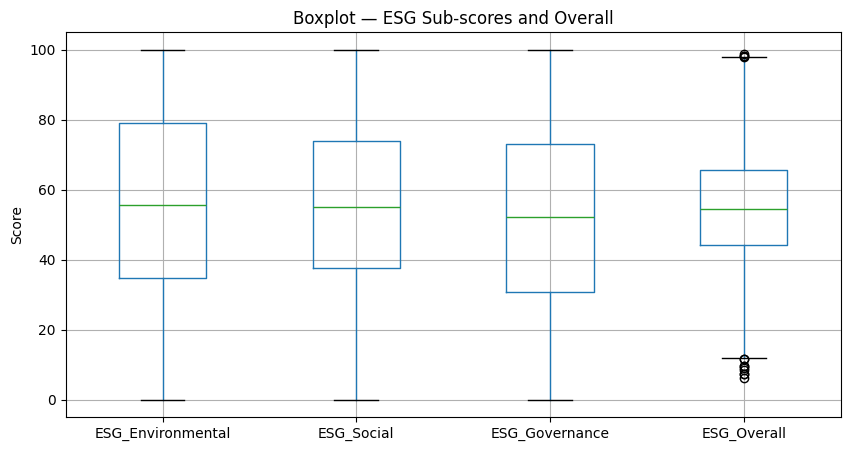

In [15]:
# Univariate Analysis — Boxplots for ESG Sub-scores
plt.figure(figsize=(10, 5))
data[['ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'ESG_Overall']].boxplot()
plt.title("Boxplot — ESG Sub-scores and Overall")
plt.ylabel("Score")
plt.show()

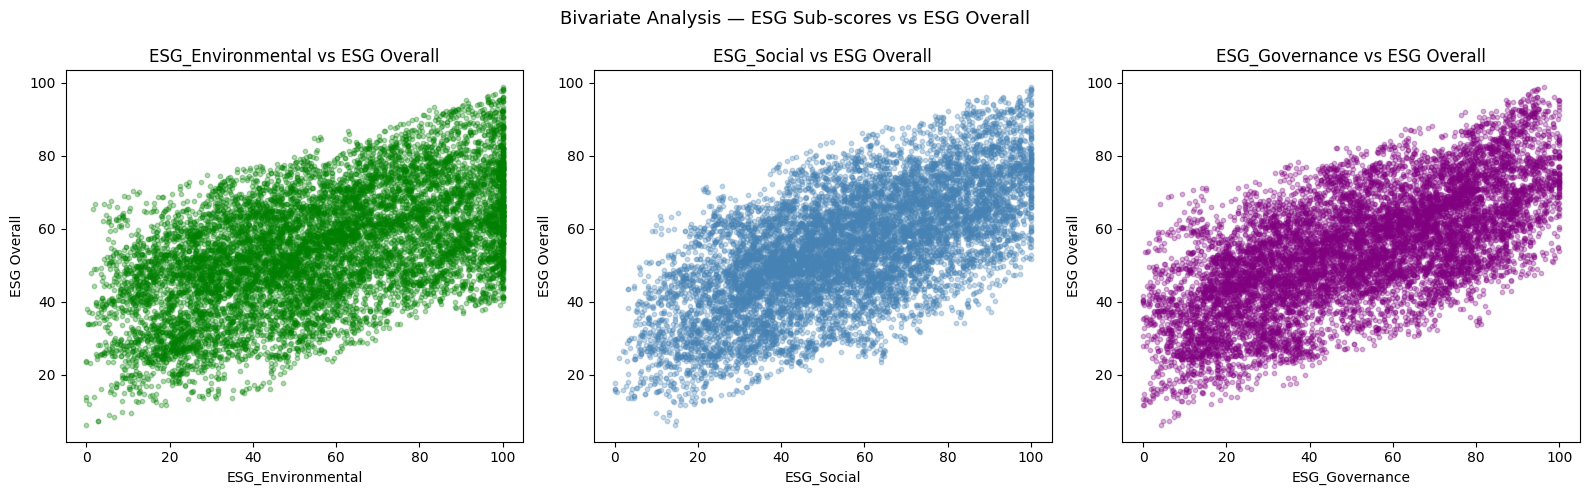

In [16]:
# Bivariate Analysis — ESG Sub-scores vs ESG Overall
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sub_scores = ['ESG_Environmental', 'ESG_Social', 'ESG_Governance']
colors = ['green', 'steelblue', 'purple']

for i, col in enumerate(sub_scores):
    axes[i].scatter(data[col], data['ESG_Overall'], alpha=0.3, s=10, color=colors[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('ESG Overall')
    axes[i].set_title(f'{col} vs ESG Overall')

plt.suptitle("Bivariate Analysis — ESG Sub-scores vs ESG Overall", fontsize=13)
plt.tight_layout()
plt.show()

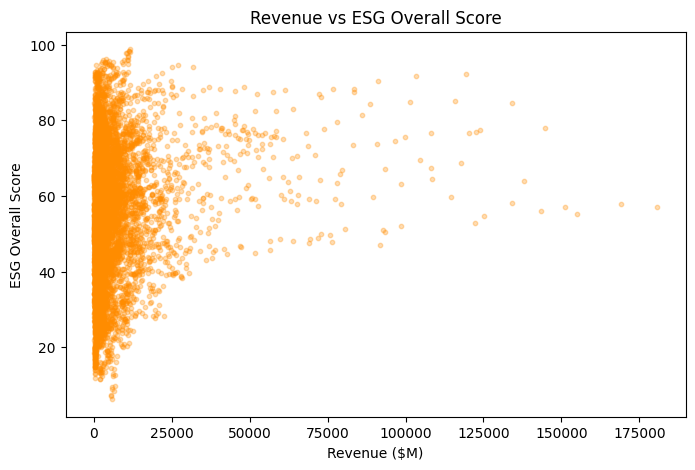

In [17]:
# Bivariate Analysis — Revenue vs ESG Overall
plt.figure(figsize=(8, 5))
plt.scatter(data['Revenue'], data['ESG_Overall'], alpha=0.3, s=10, color='darkorange')
plt.xlabel("Revenue ($M)")
plt.ylabel("ESG Overall Score")
plt.title("Revenue vs ESG Overall Score")
plt.show()

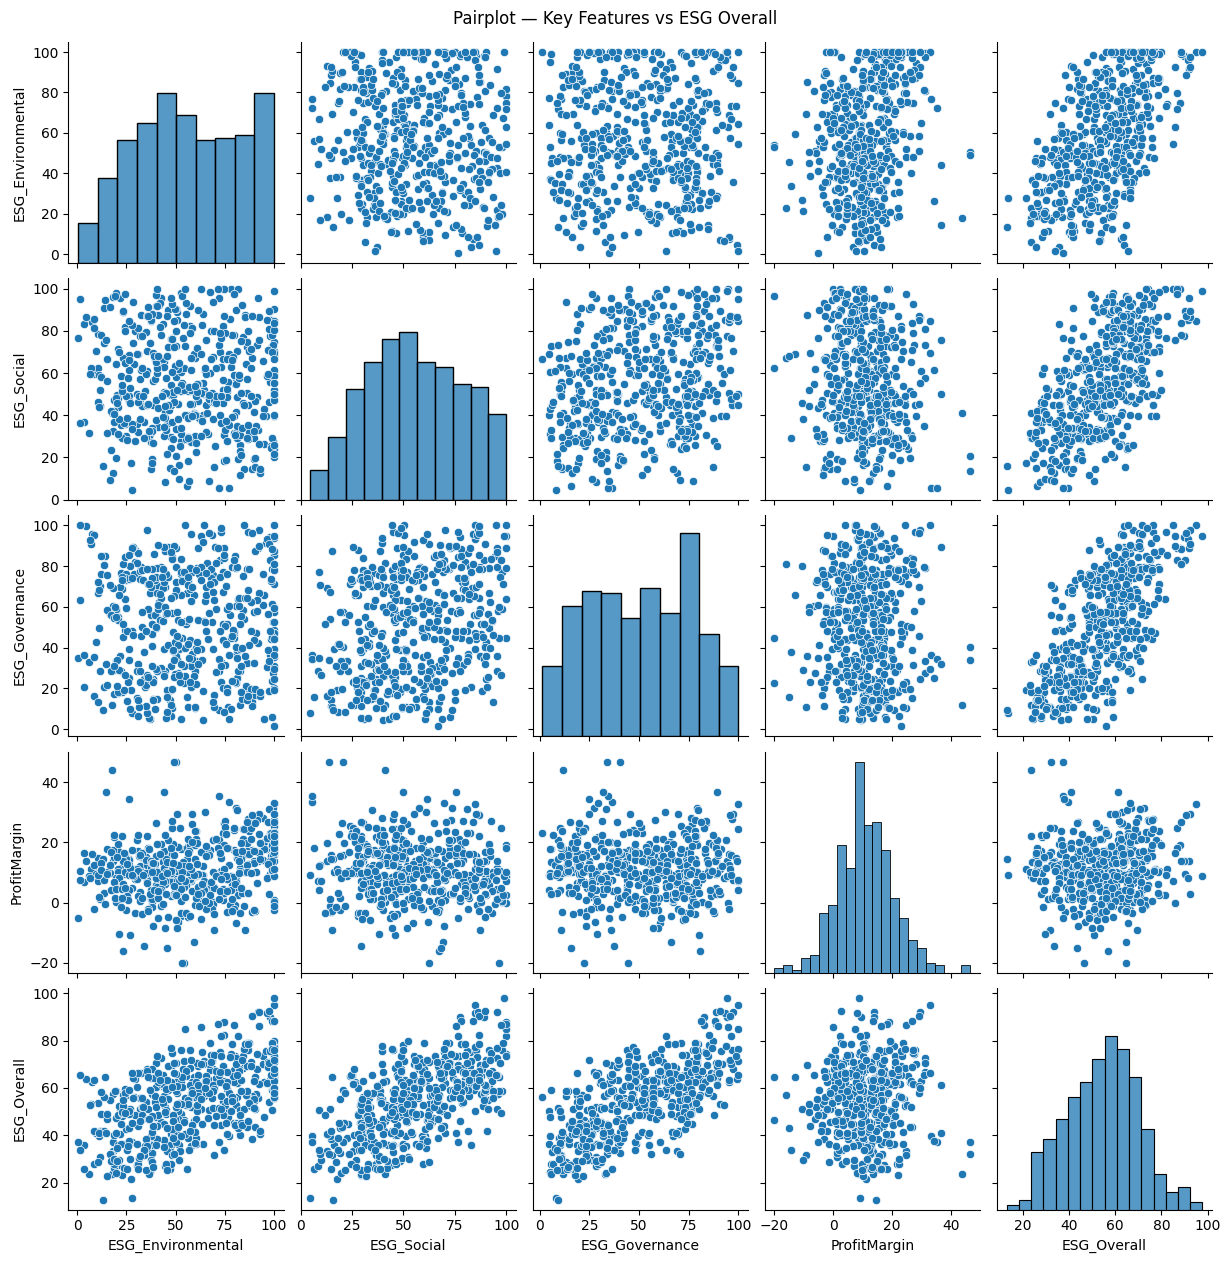

In [18]:
# Multivariate Analysis — Pairplot (key features)
pairplot_cols = ['ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'ProfitMargin', 'ESG_Overall']
sns.pairplot(data[pairplot_cols].sample(500, random_state=42))
plt.suptitle("Pairplot — Key Features vs ESG Overall", y=1.01)
plt.show()

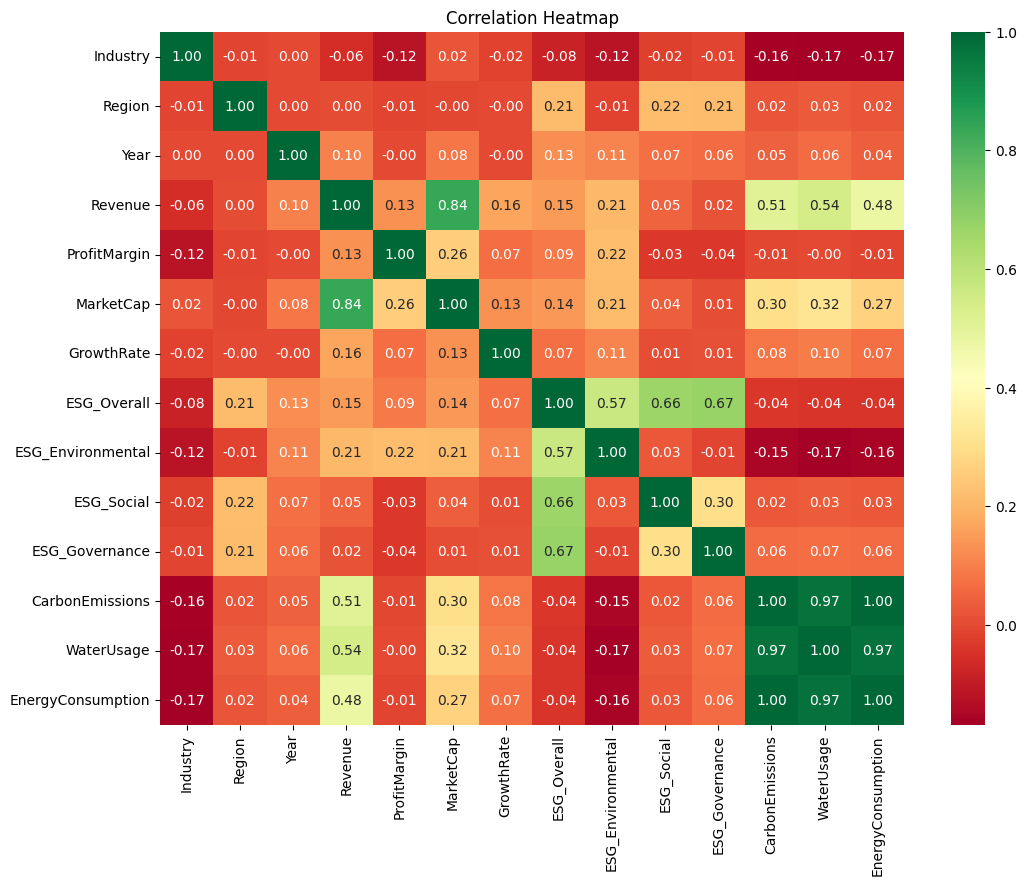

In [19]:
# Multivariate Analysis — Correlation Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn', fmt='0.2f')
plt.title("Correlation Heatmap")
plt.show()

# Step 6: Splitting the Data into Features and Target Variable

In [20]:
data.head()

,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,5,3,2015,459.2,6.0,337.5,4.3,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,5,3,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,5,3,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,5,3,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,5,3,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [21]:
X = data.drop("ESG_Overall", axis=1)   # Features
y = data["ESG_Overall"]                # Target

type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

# Step 7: Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (8800, 13)
X_test shape:  (2200, 13)
y_train shape: (8800,)
y_test shape:  (2200,)


In [24]:
# Feature Scaling — required for Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied — fit on train, transform on test (no data leakage)")

StandardScaler applied — fit on train, transform on test (no data leakage)


# Step 8: Model Training

In [25]:
model = Ridge(alpha=1.0)

model.fit(X_train_scaled, y_train)    # fit means train

Ridge()

In [26]:
# Display model coefficients and intercept
# ESG_Score = m1*x1 + m2*x2 + ... + m13*x13 + c

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print("\nModel Intercept:")
print(model.intercept_)


Model Coefficients:
  Industry: 0.0001
  Region: 0.0002
  Year: -0.0002
  Revenue: 0.0004
  ProfitMargin: 0.0008
  MarketCap: -0.0007
  GrowthRate: 0.0001
  ESG_Environmental: 8.9351
  ESG_Social: 7.8050
  ESG_Governance: 8.4512
  CarbonEmissions: -0.0022
  WaterUsage: -0.0024
  EnergyConsumption: 0.0039

Model Intercept:
54.701238636363634


# Step 9: Predictions on the Test Set

In [27]:
y_pred = model.predict(X_test_scaled)

# Step 10: Model Evaluation

In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

In [29]:
print("\nModel Evaluation:")
print(f"Mean Absolute Error : {mae:.4f}")
print(f"Mean Squared Error  : {mse:.4f}")
print(f"R-squared           : {r2:.4f}")


Model Evaluation:
Mean Absolute Error : 0.0264
Mean Squared Error  : 0.0011
R-squared           : 1.0000


In [30]:
data['ESG_Overall'].mean()

np.float64(54.615272727272725)

#### 1. Mean Absolute Error (MAE)

This means that on average, the model's predicted ESG score is off by approximately this many points out of 100.

- Since the average ESG score is around 54.6, a low MAE means the model is highly accurate.
- Good accuracy — small error relative to the full 0–100 ESG scale.

#### 2. Mean Squared Error (MSE)

- This penalizes larger prediction errors more heavily than MAE.
- Lower is better — a low MSE means the model rarely makes large mistakes.

`MSE is like MAE, but tougher on big mistakes. A low MSE means the model is consistent and rarely drifts far from the actual score.`

#### 3. R-squared (R²)

R² tells us how much of the variation in ESG score our model can explain.

- 1.0 = perfect model
- 0   = model knows nothing

💡 The model explains a very high percentage of the changes in ESG score — excellent performance for a regression task on sustainability data.

In [31]:
# Cross Validation — check model stability across 10 folds
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=10, scoring='r2')
print(f"Cross Validation R² Scores: {[round(s, 4) for s in cv_scores]}")
print(f"Mean CV R²  : {cv_scores.mean():.4f}")
print(f"Std Dev CV  : {cv_scores.std():.4f}")

Cross Validation R² Scores: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Mean CV R²  : 1.0000
Std Dev CV  : 0.0000


# Step 11: Visualizing Predictions

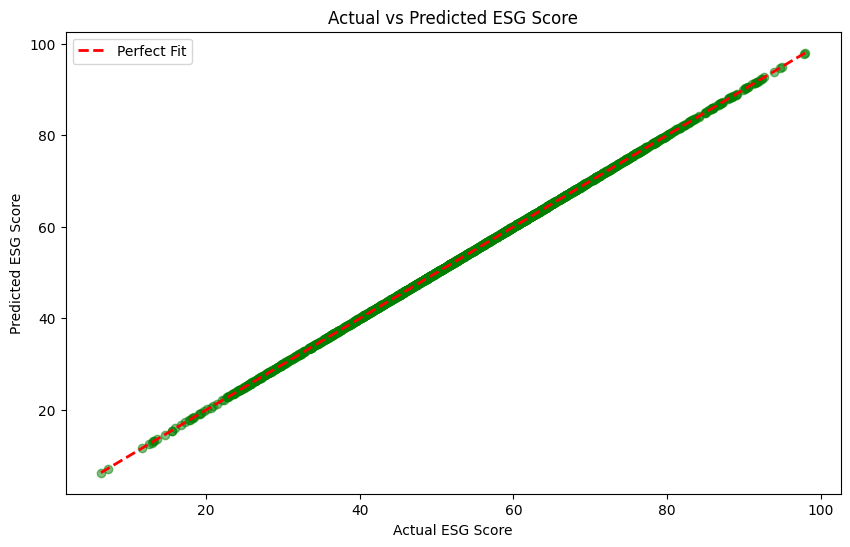

In [32]:
# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel("Actual ESG Score")
plt.ylabel("Predicted ESG Score")
plt.title("Actual vs Predicted ESG Score")
plt.legend()
plt.show()

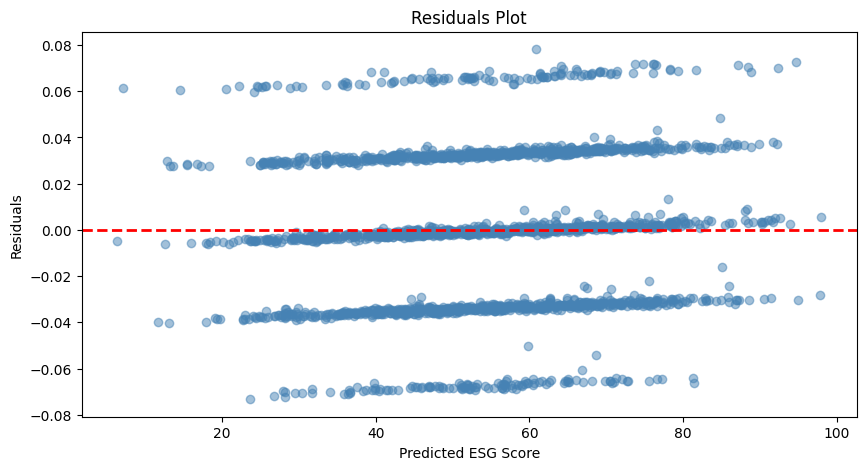

In [33]:
# Residuals Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, color='steelblue', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted ESG Score")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

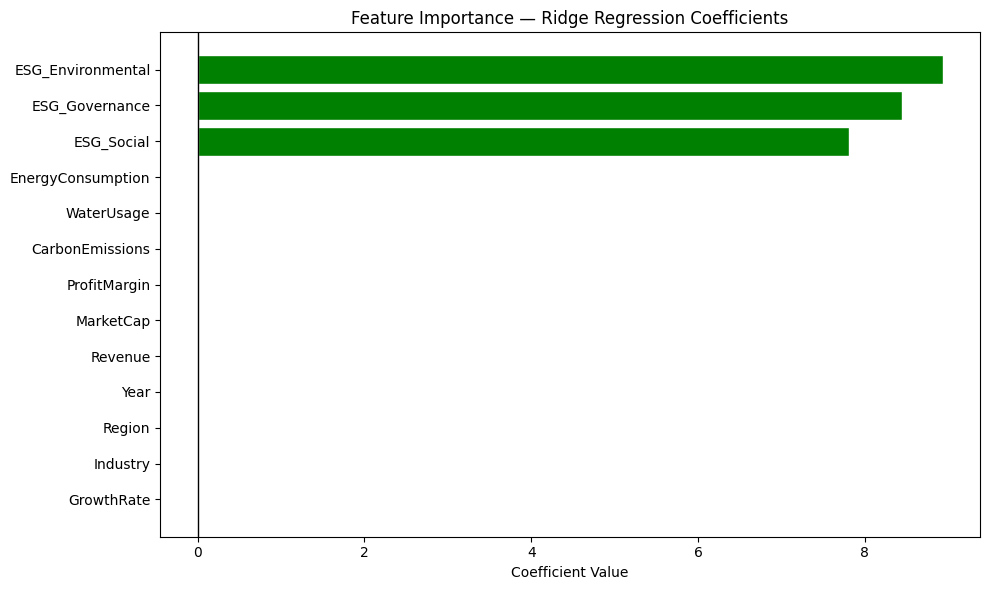

In [34]:
# Feature Importance — Model Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel("Coefficient Value")
plt.title("Feature Importance — Ridge Regression Coefficients")
plt.tight_layout()
plt.show()

In [35]:
# Save the model and preprocessing objects
joblib.dump(model,       "esg_ridge_model.pkl")
joblib.dump(scaler,      "esg_scaler.pkl")
joblib.dump(le_industry, "le_industry.pkl")
joblib.dump(le_region,   "le_region.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

print("Model saved as 'esg_ridge_model.pkl'")

Model saved as 'esg_ridge_model.pkl'


# Step 12: User Input for Prediction

In [36]:
def predict_esg_score():
    print("\nEnter the following company details for ESG Score Prediction:")

    # Collect inputs
    industry_input = input(f"Industry ({', '.join(le_industry.classes_)}): ")
    region_input   = input(f"Region ({', '.join(le_region.classes_)}): ")
    year           = float(input("Year (e.g. 2024): "))
    revenue        = float(input("Revenue ($M): "))
    profit_margin  = float(input("Profit Margin (%): "))
    market_cap     = float(input("Market Cap ($M): "))
    growth_rate    = float(input("Growth Rate (%): "))
    esg_env        = float(input("ESG Environmental Score (0-100): "))
    esg_soc        = float(input("ESG Social Score (0-100): "))
    esg_gov        = float(input("ESG Governance Score (0-100): "))
    carbon         = float(input("Carbon Emissions (tonnes): "))
    water          = float(input("Water Usage (m³): "))
    energy         = float(input("Energy Consumption (MWh): "))

    # Encode categorical inputs
    industry_enc = le_industry.transform([industry_input])[0]
    region_enc   = le_region.transform([region_input])[0]

    # Create a DataFrame matching training features
    loaded_features = joblib.load("feature_names.pkl")
    user_data = pd.DataFrame([{
        'Industry'          : industry_enc,
        'Region'            : region_enc,
        'Year'              : year,
        'Revenue'           : revenue,
        'ProfitMargin'      : profit_margin,
        'MarketCap'         : market_cap,
        'GrowthRate'        : growth_rate,
        'ESG_Environmental' : esg_env,
        'ESG_Social'        : esg_soc,
        'ESG_Governance'    : esg_gov,
        'CarbonEmissions'   : carbon,
        'WaterUsage'        : water,
        'EnergyConsumption' : energy
    }])[loaded_features]

    # Load model and scaler, then predict
    loaded_model  = joblib.load("esg_ridge_model.pkl")
    loaded_scaler = joblib.load("esg_scaler.pkl")

    user_scaled  = loaded_scaler.transform(user_data)
    prediction   = loaded_model.predict(user_scaled)
    final_score  = float(np.clip(prediction[0], 0, 100))

    print(f"\nPredicted ESG Overall Score: {final_score:.2f} / 100")

    if final_score >= 70:
        print("ESG Rating: HIGH PERFORMER — Strong sustainability profile")
    elif final_score >= 45:
        print("ESG Rating: MODERATE PERFORMER — Room for improvement")
    else:
        print("ESG Rating: NEEDS IMPROVEMENT — Significant ESG gaps identified")

In [ ]:
##Input -->

#Industry: Technology
#Region: North America
#Year: 2024
#Revenue ($M): 8500
#Profit Margin (%): 18.5
#Market Cap ($M): 45000
#Growth Rate (%): 12.3
#ESG Environmental Score (0-100): 72
#ESG Social Score (0-100): 68
#ESG Governance Score (0-100): 80
#Carbon Emissions (tonnes): 15000
#Water Usage (m³): 62000
#Energy Consumption (MWh): 250000

In [38]:
predict_esg_score()


Enter the following company details for ESG Score Prediction:
Industry (Consumer Goods, Energy, Finance, Healthcare, Manufacturing, Retail, Technology, Transportation, Utilities): Technology
Region (Africa, Asia, Europe, Latin America, Middle East, North America, Oceania): North America
Year (e.g. 2024): 2024
Revenue ($M): 8500
Profit Margin (%): 18.5
Market Cap ($M): 45000
Growth Rate (%): 12.3
ESG Environmental Score (0-100): 72
ESG Social Score (0-100): 68
ESG Governance Score (0-100): 80
Carbon Emissions (tonnes): 15000
Water Usage (m³): 62000
Energy Consumption (MWh): 250000

Predicted ESG Overall Score: 73.33 / 100
ESG Rating: HIGH PERFORMER — Strong sustainability profile
